## End-to-End ML Pipeline with Scikit-learn Pipeline API

### Objective:
Build a reusable and production-ready machine learning pipeline for predicting customer
churn.
### Dataset:
Telco Churn Dataset
### Instructions:
● Implement data preprocessing steps (e.g., scaling, encoding) using Pipeline

● Train models like Logistic Regression and Random Forest

● Use GridSearchCV for hyperparameter tuning

● Export the complete pipeline using joblib

### Skills Gained:
● ML pipeline construction

● Hyperparameter tuning with GridSearch

● Model export and reusability

● Production-readiness practices

## Step:01 Requirement Libraries

In [147]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## Step:02 Load DataSet

In [148]:
df = pd.read_csv(r'C:\Users\Muhammad Yahya\Downloads\DevelopersHub-AI-Internship\Task02_End_to_End_ML_Pipeline_with_Scikit-learn _Pipeline_API\WA_Fn-UseC_-Telco-Customer-Churn.csv')

## Step:03 Exploration DataSet

In [149]:
df.head() #Top 5 Rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [150]:
df.tail() #Bottom 5 Rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [151]:
df.shape

(7043, 21)

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##### Check Statistical Summary

In [153]:
df.describe() #This is pandas most powerfull method

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Step:04 Preprocessing 

In [154]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

##### Check Duplicate Values

In [155]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [156]:
for e in df['TotalCharges']:

     if (e == ' ' or e == str):
          print('This Feature/Column Data_Type is Object/String.\n And I See Some Empty Spaces')
          
print('\nNow Solve Problem Below')     

This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces
This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces
This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces
This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces
This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces
This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces
This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces
This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces
This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces
This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces
This Feature/Column Data_Type is Object/String.
 And I See Some Empty Spaces

Now Solve Problem Below


In [157]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

##### Exploration Particular Feature

In [158]:
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


##### Impute 'NaN' Values

In [159]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [160]:
for satisfied in df['TotalCharges']:

    if (satisfied == float and satisfied == None):
        print('Impute NaN/Drop NaN')

print('Uptodate')
print(f'str-->to-->{df['TotalCharges'].dtype} , NaN-->impute-->from-->mean')

Uptodate
str-->to-->float64 , NaN-->impute-->from-->mean


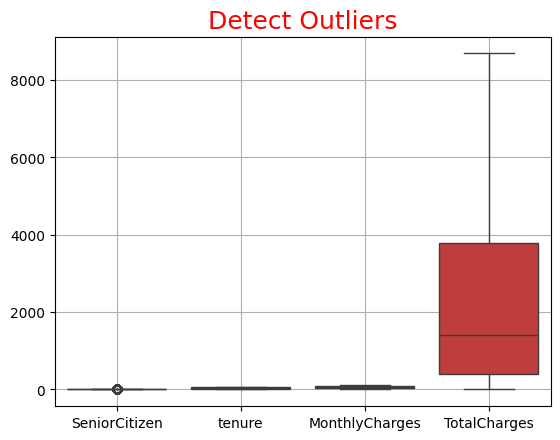

In [161]:
sns.boxplot(df)
plt.title('Detect Outliers' , color='r' , fontsize=18)
plt.grid()
plt.show()

## Step: 05 Feature Engineering & Pipeline Setup

Now Seperate Features , Target/Label

In [162]:
X = df.drop(['customerID' , 'Churn'] , axis=1)

y = df['Churn']
 

In [163]:
emp = []
for possibility in y:

    if possibility == 'Yes':
        emp.append(1)

    else:
        emp.append(0)    

print(emp)

[0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 

Create two variables and store (categorical , numerical features values)

In [164]:
numeric_features = X.select_dtypes(include=['int64' , 'float64']).columns.tolist()

categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical DataTypes= {numeric_features}\nCategorical DataTypes= {categorical_features}')

Numerical DataTypes= ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical DataTypes= ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


##### Create Pipeline Compenents

In [165]:
# Numeric Pipeline (Scaling)
numeric_transformer = Pipeline(steps=[('Scalar' , StandardScaler())])

# Categorical pipeline (Encoding)
categorical_transformer = Pipeline(steps=[('OneHotEncode' , OneHotEncoder(handle_unknown='ignore'))])

# combine
preprocessor = ColumnTransformer(transformers=[

    ('num' , numeric_transformer , numeric_features),
    ('categorical' ,categorical_transformer , categorical_features)
    
    ])


## Step: 06 Training with Model Pipeline

##### 1. Final Pipeline With Classifier

In [166]:
model_pipeline = Pipeline(steps=[

    ('Preprocessor' , preprocessor),
    ('Classifier' , RandomForestClassifier(random_state=42))

])

##### 2. Split Data 

In [167]:
X_train , X_test , y_train , y_test = train_test_split(X, emp, test_size=0.2 , random_state=42)

# Fit Pipeline
model_pipeline.fit(X_train , y_train)
print(f'Model Pipeline Trained Successfully!{model_pipeline}')

Model Pipeline Trained Successfully!Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Scalar',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('OneHotEncode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
              

## Step: 07 

##### 1. Create Parameters Grid

In [168]:
param_grid = {
    'Classifier__n_estimators': [100, 200],       
    'Classifier__max_depth': [None, 10, 20],     
    'Classifier__min_samples_split': [2, 5]       
}

##### 2. GridSearchCV setup karein

In [169]:
grid_search = GridSearchCV( 

    estimator = model_pipeline,
    param_grid = param_grid,      
    cv = 5,                       
    scoring = 'f1',              
    n_jobs = -1,                  
    verbose = 2                    
)

##### 3. Model Train

In [170]:
print("Finding best model settings.. please wait.")
grid_search.fit(X_train, y_train)

Finding best model settings.. please wait.
Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'Classifier__max_depth': [None, 10, ...], 'Classifier__min_samples_split': [2, 5], 'Classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

##### 4. Best Results check

In [171]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

Best Parameters: {'Classifier__max_depth': 10, 'Classifier__min_samples_split': 5, 'Classifier__n_estimators': 200}
Best Score: 0.5674371479774384


## Step: 08 Export (Joblib)

In [172]:
# Best pipeline save 
best_model = grid_search.best_estimator_
joblib.dump(best_model, 'telco_churn_production_model.joblib')

print("Final Production-Ready Pipeline Saved!")

Final Production-Ready Pipeline Saved!


## Step:09 Model Loading

In [173]:
# testing
loaded_model = joblib.load('telco_churn_production_model.joblib')
print("Model loaded successfully!")

Model loaded successfully!
